## 0. Learning phase

In [1]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split


In [2]:
df = pd.read_csv('features2.csv')
y = df['label']
X = df.drop(['label', 'filepath', 'timestamp_year', 'timestamp_is_zero', 'family', 'subsystem'], axis=1) #

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
train_data = lgb.Dataset(data=X_train, label=y_train)
test_data = lgb.Dataset(data=X_test, label=y_test, reference=train_data) 

In [5]:
params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 31,          # default, constrains tree complexity
    "min_child_samples": 30,   # require more samples per leaf
    "lambda_l1": 0.1,          # L1 regularisation
    "lambda_l2": 0.1,          # L2 regularisation
    "feature_fraction": 0.8,   # use 80% of features per tree (adds randomness)
    "bagging_fraction": 0.8,   # use 80% of data per tree
    "bagging_freq": 5,
}

In [6]:
booster = lgb.train(
    params=params,
    train_set=train_data,
    num_boost_round=100,
    valid_sets=[train_data, test_data],
    callbacks=[lgb.log_evaluation(period=10),
               lgb.early_stopping(stopping_rounds=50)] 
)

[LightGBM] [Info] Number of positive: 703, number of negative: 758
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000565 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2256
[LightGBM] [Info] Number of data points in the train set: 1461, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.481177 -> initscore=-0.075326
[LightGBM] [Info] Start training from score -0.075326
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

## 1. LightGBM Feature Importance

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

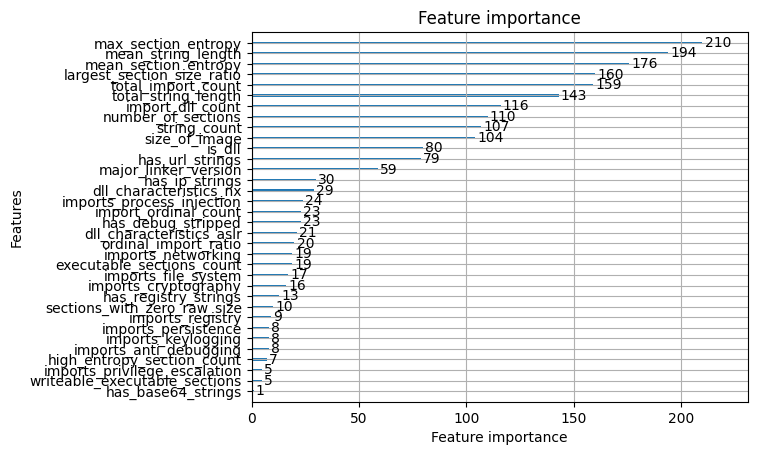

In [7]:
lgb.plot_importance(booster, importance_type='split', max_num_features=50)

## 2. Confusion matrix

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_proba = booster.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['benign', 'malicious']))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

      benign       0.94      0.95      0.94       190
   malicious       0.94      0.94      0.94       176

    accuracy                           0.94       366
   macro avg       0.94      0.94      0.94       366
weighted avg       0.94      0.94      0.94       366

[[180  10]
 [ 11 165]]


### Concern 1: Usefulness of mean_string_length

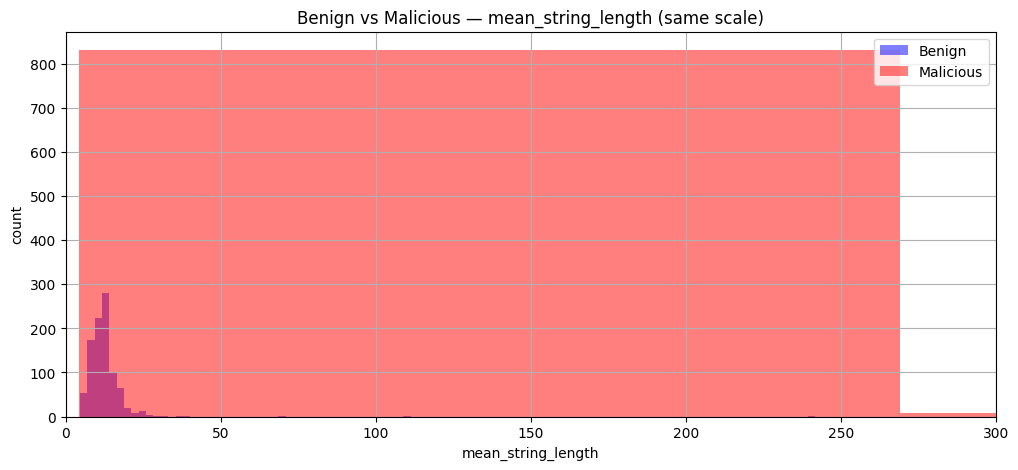

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

df[df.label == 0]['mean_string_length'].hist(
    bins=100, ax=ax, alpha=0.5, label='Benign', color='blue'
)
df[df.label == 1]['mean_string_length'].hist(
    bins=100, ax=ax, alpha=0.5, label='Malicious', color='red'
)

ax.set_xlim(0, 300) 
ax.legend()
ax.set_xlabel('mean_string_length')
ax.set_ylabel('count')
ax.set_title('Benign vs Malicious — mean_string_length (same scale)')
plt.show()

As we can see, while the values of both types of files completely intercept, the feature is still useful for detecting malware, as the range of values of malware greatly exceeds the range of values for benign files

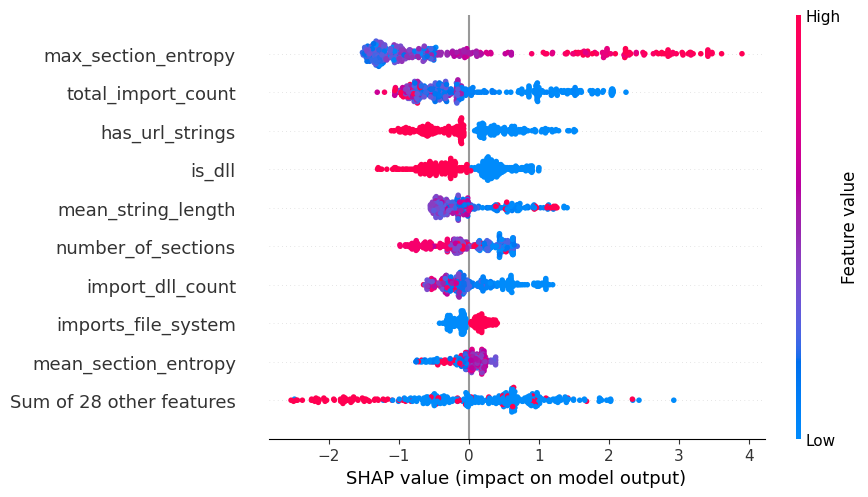

In [10]:
import shap

shap.initjs()
explainer = shap.Explainer(booster)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

Shap value analysis confirms the conclusion one cell above. The graph also 

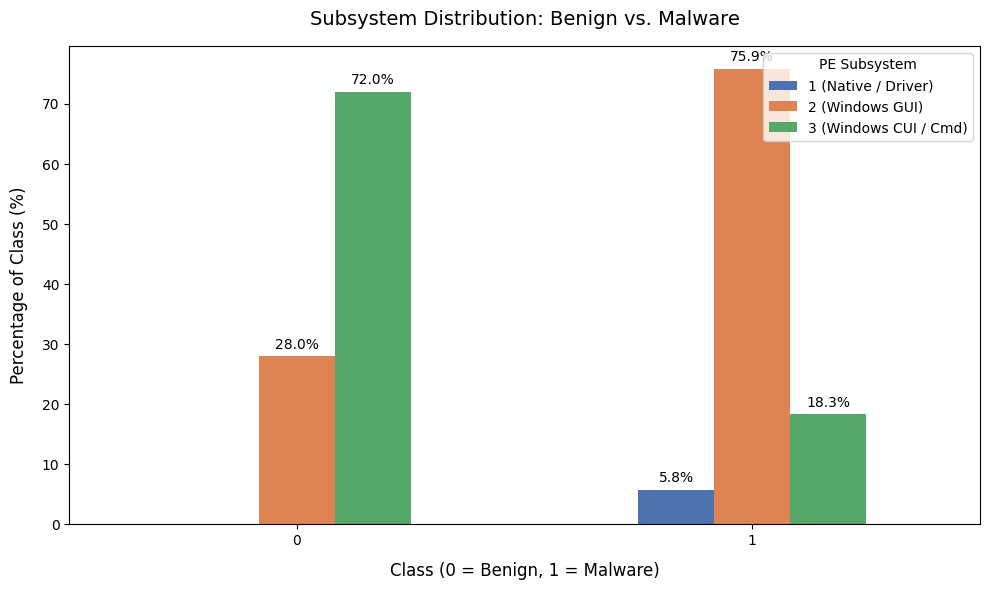

In [ ]:
import matplotlib.pyplot as plt

distribution = pd.crosstab(df['label'], df['subsystem'], normalize='index') * 100
ax = distribution.plot(kind='bar', figsize=(10, 6), rot=0, 
                       color=['#4C72B0', '#DD8452', '#55A868'])

plt.title('Subsystem Distribution: Benign vs. Malware', fontsize=14, pad=15)
plt.xlabel('Class (0 = Benign, 1 = Malware)', fontsize=12, labelpad=10)
plt.ylabel('Percentage of Class (%)', fontsize=12, labelpad=10)

plt.legend(['1 (Native / Driver)', '2 (Windows GUI)', '3 (Windows CUI / Cmd)'], 
           title='PE Subsystem', loc='upper right')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 3), 
                    textcoords='offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()

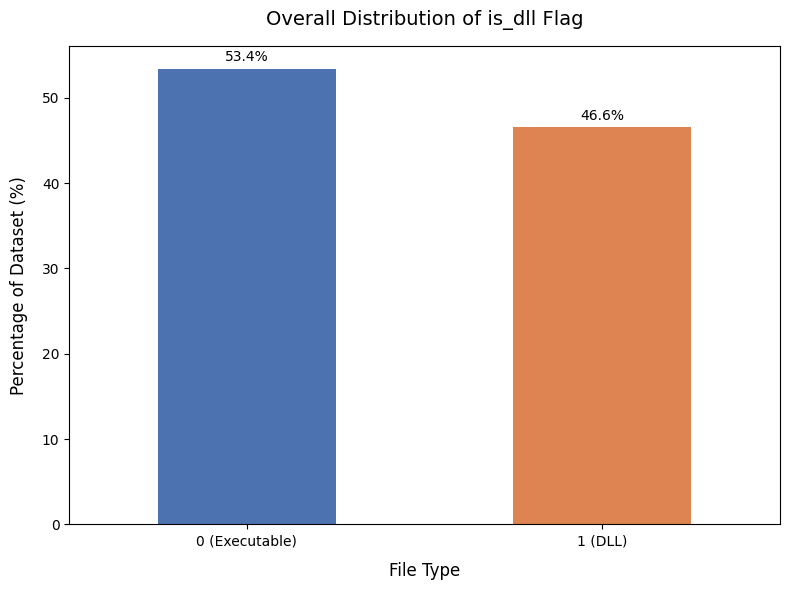

In [ ]:
import matplotlib.pyplot as plt

distribution = df['is_dll'].value_counts(normalize=True).sort_index() * 100

ax = distribution.plot(kind='bar', figsize=(8, 6), rot=0, 
                       color=['#4C72B0', '#DD8452'])
plt.title('Overall Distribution of is_dll Flag', fontsize=14, pad=15)
plt.xlabel('File Type', fontsize=12, labelpad=10)
plt.ylabel('Percentage of Dataset (%)', fontsize=12, labelpad=10)

plt.xticks([0, 1], ['0 (Executable)', '1 (DLL)'])

for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 3), 
                    textcoords='offset points',
                    fontsize=10)

plt.tight_layout()
plt.show()

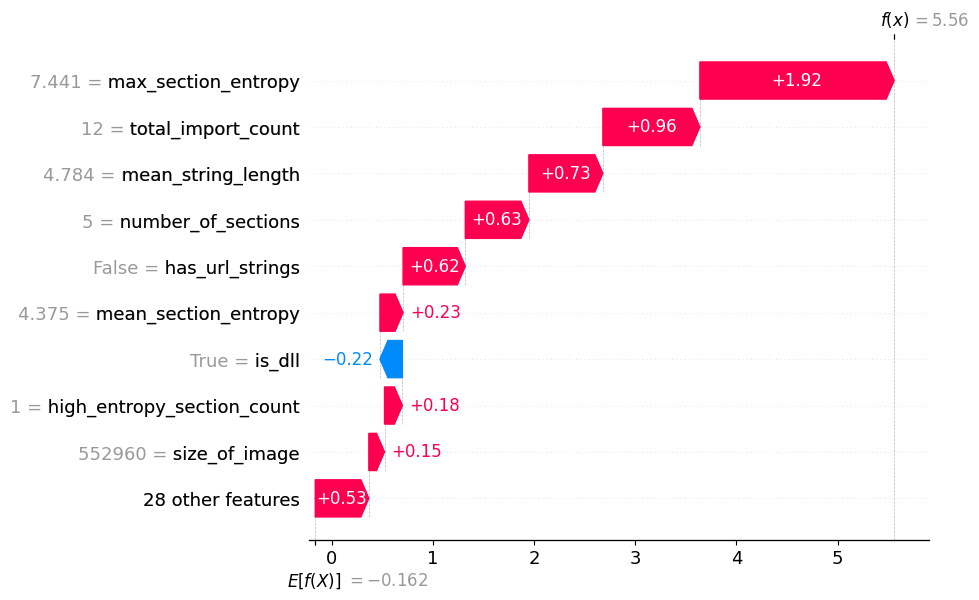

In [12]:
shap.plots.waterfall(shap_values[8])

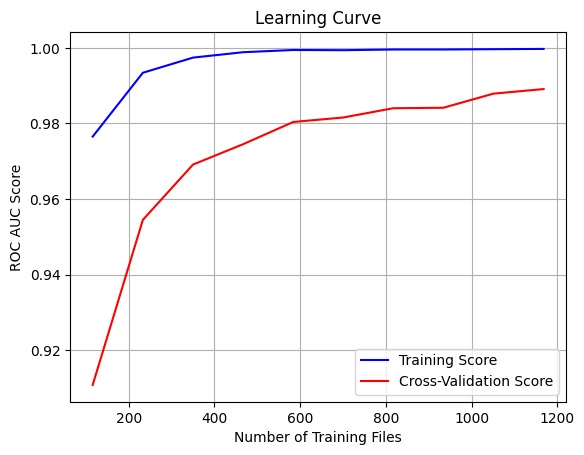

In [13]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np
from lightgbm import LGBMClassifier

clf = LGBMClassifier(**params)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=clf, 
    X=X_train, 
    y=y_train, 
    cv=5, 
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Training Score", color='blue')
plt.plot(train_sizes, test_mean, label="Cross-Validation Score", color='red')
plt.title("Learning Curve")
plt.xlabel("Number of Training Files")
plt.ylabel("ROC AUC Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [ ]:

from sklearn.metrics import classification_report, roc_auc_score, f1_score

feature_cols = [col for col in df.columns if col not in ['label', 'family', 'subsystem' , 'filepath', 'timestamp_year', 'timestamp_is_zero']]

benign_df = df[df['label'] == 0]
malware_df = df[df['label'] == 1]

malware_families = malware_df['family'].unique()

lgbm_scores = []

print(f"Number of families: {len(malware_families)}")

for family in malware_families:

    print(f"\n--- Testing Holdout Family: {family} ---")
    test_malware = malware_df[malware_df['family'] == family]
    print(f"number of data points in family: {len(test_malware)}")
    train_malware = malware_df[malware_df['family'] != family]
    
    train_benign, test_benign = train_test_split(benign_df, test_size=0.2, random_state=42)
    
    train_df = pd.concat([train_benign, train_malware]).sample(frac=1, random_state=42) 
    test_df = pd.concat([test_benign, test_malware]).sample(frac=1, random_state=42)
    
    X_train, y_train = train_df[feature_cols], train_df['label']
    X_test, y_test = test_df[feature_cols], test_df['label']
    
    lgbm = LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    lgbm.fit(X_train, y_train)
    lgbm_preds = lgbm.predict(X_test)
    
    lgbm_f1 = f1_score(y_test, lgbm_preds)
    lgbm_scores.append(lgbm_f1)
    print(f"LightGBM F1-Score: {lgbm_f1:.4f}")
    

print("\n=== Final LOFO CV Results ===")
print(f"Average LightGBM F1: {np.mean(lgbm_scores):.4f}")


Number of families: 9

--- Testing Holdout Family: /home/osboxes/Desktop/malware/trojan_unpacked ---
number of data points in family: 100
[LightGBM] [Info] Number of positive: 779, number of negative: 758
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000839 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2268
[LightGBM] [Info] Number of data points in the train set: 1537, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.506831 -> initscore=0.027328
[LightGBM] [Info] Start training from score 0.027328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM F1-Score: 0.9216

--- Testing Holdout Family: /home/osboxes/Desktop/malware/loader_unpacked ---
number of data points in family: 100
[LightGBM] [Info] Number of positive: 779, number of negative: 758
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001